# 03 — Model Karşılaştırması
LightGBM · XGBoost · CatBoost · Random Forest

Ortak eval framework → leaderboard tablosu → kazanan model seçimi

**Veri:** `ml_dataset_multiyear.parquet`

In [14]:
%pip install lightgbm xgboost catboost scikit-learn matplotlib seaborn joblib -q

Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

BASE_DIR  = Path('..').resolve()
DATA_DIR  = BASE_DIR / 'data'
MODEL_DIR = BASE_DIR / 'models'
MODEL_DIR.mkdir(exist_ok=True)

COMBO        = ['district_name', 'crop_name', 'variety_name', 'year']  # GÜNCELLENDI
TARGET       = 'twso_final'
RANDOM_STATE = 42
print('Hazır.')

Hazır.


## 1. Veri & Feature Yükle

In [16]:
from pyarrow import parquet as pq

parquet_path = DATA_DIR / 'ml_dataset_multiyear.parquet'
try:
    df_raw = pd.read_parquet(parquet_path, engine='pyarrow')
except OSError as exc:
    print(f'pd.read_parquet hata verdi, pyarrow direct read deneniyor: {exc}')
    df_raw = pq.read_table(parquet_path).to_pandas()

if 'split' not in df_raw.columns:
    if 'year' in df_raw.columns:
        split_map = {2014: 'train', 2015: 'train', 2016: 'train', 2017: 'train', 2018: 'train', 2019: 'train', 2020: 'train', 2021: 'train', 2022: 'val', 2023: 'val', 2024: 'test'}
        df_raw['split'] = df_raw['year'].map(split_map).fillna('holdout')
        print("'split' kolonu parquet içinde yoktu; year'dan türetildi.")
    else:
        raise KeyError("'split' kolonu bulunamadı ve year kolonu da yok; veri seti uyumsuz.")

df = df_raw[df_raw['DVS'] < 1.0].copy().reset_index(drop=True)
train_df = df[df['split'] == 'train'].copy().reset_index(drop=True)
val_df   = df[df['split'] == 'val'].copy().reset_index(drop=True)
test_df  = df[df['split'] == 'test'].copy().reset_index(drop=True)

# 2. Feature listesini yükle veya oluştur (year/season_id/split meta kolonlar çıkar)
feat_path = MODEL_DIR / 'feature_cols.pkl'
if feat_path.exists():
    FEATURE_COLS = joblib.load(feat_path)
    # Eski pkl'de rolling varsa temizle
    FEATURE_COLS = [c for c in FEATURE_COLS if not c.startswith('roll')]
    print('Feature listesi yüklendi (sızdırıcı sütunlar temizlenmiş).')
else:
    LEAKY_COLS = ['TWSO', 'TAGP', 'TWLV', 'TWST', 'TWRT']
    ROLLING_COLS = [c for c in df.columns if c.startswith('roll')]  # roll7_*, roll30_*
    DROP = ['date','district_name','crop_name','variety_name','soil_type','growth_stage',
            'year','season_id','split','tbase', TARGET, *LEAKY_COLS, *ROLLING_COLS]
    FEATURE_COLS = [c for c in df.columns if c not in DROP]
    joblib.dump(FEATURE_COLS, feat_path)
    print('Feature listesi yeniden oluşturuldu ve kaydedildi.')

X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET].copy()
X_val   = val_df[FEATURE_COLS].copy()
y_val   = val_df[TARGET].copy()
X_test  = test_df[FEATURE_COLS].copy()
y_test  = test_df[TARGET].copy()

train_groups = train_df['district_name'].astype(str) + '_' + train_df['crop_name'].astype(str)
gkf = GroupKFold(n_splits=5)
CV_SPLITS = list(gkf.split(X_train, y_train, train_groups))

print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}  |  Features: {len(FEATURE_COLS)}')
print(f'Split dağılımı: {df["split"].value_counts().to_dict()}')
print(f'Train years: {sorted(train_df["year"].unique().tolist())[:3]} ... {sorted(train_df["year"].unique().tolist())[-3:]}')
print(f'CV fold sayısı: {len(CV_SPLITS)}')

'split' kolonu parquet içinde yoktu; year'dan türetildi.
Feature listesi yüklendi (sızdırıcı sütunlar temizlenmiş).
Train: 135,457  |  Val: 34,403  |  Test: 15,813  |  Features: 36
Split dağılımı: {'train': 135457, 'val': 34403, 'test': 15813}
Train years: [2014, 2015, 2016] ... [2019, 2020, 2021]
CV fold sayısı: 5


## 2. Model Tanımları

In [17]:
# LightGBM — 02'de kaydedilen en iyi modeli yükle (varsa)
lgbm_path = MODEL_DIR / 'lgbm_yield_final.pkl'
if lgbm_path.exists():
    lgbm_model = joblib.load(lgbm_path)
    print('LightGBM: kaydedilmiş model yüklendi.')
else:
    lgbm_model = lgb.LGBMRegressor(
        n_estimators=1000, learning_rate=0.05, num_leaves=127,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )
    print('LightGBM: varsayılan parametreler.')

xgb_model = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=20,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    early_stopping_rounds=50
)

cat_model = CatBoostRegressor(
    iterations=1000, learning_rate=0.05, depth=6,
    random_seed=RANDOM_STATE, verbose=0,
    early_stopping_rounds=50
)

rf_model = RandomForestRegressor(
    n_estimators=300, max_depth=20, min_samples_leaf=10,
    n_jobs=-1, random_state=RANDOM_STATE
)

MODELS = {
    'LightGBM':     lgbm_model,
    'XGBoost':      xgb_model,
    'CatBoost':     cat_model,
    'RandomForest': rf_model,
}
print('Model tanımları hazır.')

LightGBM: kaydedilmiş model yüklendi.
Model tanımları hazır.


## 3. Ortak Eval Framework

In [18]:
def safe_mape(y_true, y_pred, threshold=100):
    mask = y_true > threshold
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def clone_model(name, model):
    """Create a fresh model instance with the same parameters."""
    if name == 'LightGBM':
        return lgb.LGBMRegressor(**model.get_params())
    if name == 'XGBoost':
        return xgb.XGBRegressor(**model.get_params())
    if name == 'CatBoost':
        return CatBoostRegressor(**model.get_params())
    if name == 'RandomForest':
        return RandomForestRegressor(**model.get_params())
    return model.__class__(**model.get_params())


def evaluate_model(name, model, X_tr, y_tr, X_va, y_va, X_te, y_te, cv_splits, X_cv, y_cv):
    """Train, CV değerlendirme ve test metrikleri."""
    t0 = time.time()

    fit_kwargs = {}
    if name == 'XGBoost':
        fit_kwargs = {'eval_set': [(X_va, y_va)], 'verbose': False}
    elif name == 'CatBoost':
        fit_kwargs = {'eval_set': (X_va, y_va)}
    elif name == 'LightGBM' and not hasattr(model, 'booster_'):
        fit_kwargs = {
            'eval_set': [(X_va, y_va)],
            'callbacks': [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        }

    if name == 'LightGBM' and hasattr(model, 'booster_'):
        pass
    else:
        model.fit(X_tr, y_tr, **fit_kwargs)

    train_time = time.time() - t0

    cv_rmse = []
    for tr_idx, val_idx in cv_splits:
        fold_model = clone_model(name, model)
        fold_fit_kwargs = {}
        if name == 'XGBoost':
            fold_fit_kwargs = {'eval_set': [(X_cv.iloc[val_idx], y_cv.iloc[val_idx])], 'verbose': False}
        elif name == 'CatBoost':
            fold_fit_kwargs = {'eval_set': (X_cv.iloc[val_idx], y_cv.iloc[val_idx])}
        elif name == 'LightGBM':
            fold_fit_kwargs = {
                'eval_set': [(X_cv.iloc[val_idx], y_cv.iloc[val_idx])],
                'callbacks': [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
            }
        fold_model.fit(X_cv.iloc[tr_idx], y_cv.iloc[tr_idx], **fold_fit_kwargs)
        preds_val = fold_model.predict(X_cv.iloc[val_idx])
        cv_rmse.append(mean_squared_error(y_cv.iloc[val_idx], preds_val) ** 0.5)

    y_pred = model.predict(X_te)
    rmse   = mean_squared_error(y_te, y_pred) ** 0.5
    mae    = mean_absolute_error(y_te, y_pred)
    r2     = r2_score(y_te, y_pred)
    mape_s = safe_mape(y_te.values, y_pred, threshold=100)

    result = {
        'Model':        name,
        'RMSE':         round(rmse, 2),
        'MAE':          round(mae, 2),
        'R2':           round(r2, 4),
        'MAPE_safe':    round(mape_s, 2),
        'CV_RMSE_mean': round(np.mean(cv_rmse), 2),
        'CV_RMSE_std':  round(np.std(cv_rmse), 2),
        'Train_sec':    round(train_time, 1),
    }
    print(f"{name:15s} → R²={r2:.4f}  RMSE={rmse:.1f}  MAE={mae:.1f}  safeMAPE={mape_s:.2f}  ({train_time:.0f}s)")
    return result, y_pred


leaderboard_rows = []
all_preds = {}

# GÜNCELLENDI: tüm modeller aynı train/val/test split ile eğitilir ve aynı test setinde değerlendirilir.
for name, model in MODELS.items():
    row, preds = evaluate_model(
        name, model,
        X_train, y_train, X_val, y_val, X_test, y_test,
        CV_SPLITS, X_train, y_train
    )
    leaderboard_rows.append(row)
    all_preds[name] = preds

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001471 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6913
[LightGBM] [Info] Number of data points in the train set: 108331, number of used features: 36
[LightGBM] [Info] Start training from score 1771.968583
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001401 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6914
[LightGBM] [Info] Number of data points in the train set: 108359, number of used features: 36
[LightGBM] [Info] Start training from score 1923.500958
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001710 seconds.
Y

## 4. Leaderboard

In [19]:
leaderboard = pd.DataFrame(leaderboard_rows).sort_values(['R2', 'RMSE'], ascending=[False, True]).reset_index(drop=True)
leaderboard.index += 1
leaderboard.index.name = 'Rank'
print('\n══ LEADERBOARD ══')
print(leaderboard.to_string())

WINNER = leaderboard.iloc[0]['Model']
print(f'\n🏆 Kazanan: {WINNER}')


══ LEADERBOARD ══
             Model     RMSE     MAE      R2  MAPE_safe  CV_RMSE_mean  CV_RMSE_std  Train_sec
Rank                                                                                        
1         CatBoost   966.82  569.88  0.8485      60.17       1443.92       380.10        6.4
2          XGBoost  1005.86  589.10  0.8360      62.03       1436.33       279.70        1.6
3         LightGBM  1007.28  592.19  0.8356      61.21       1347.96       274.89        0.0
4     RandomForest  1213.81  651.14  0.7612      65.79       1635.78       367.72      105.1

🏆 Kazanan: CatBoost


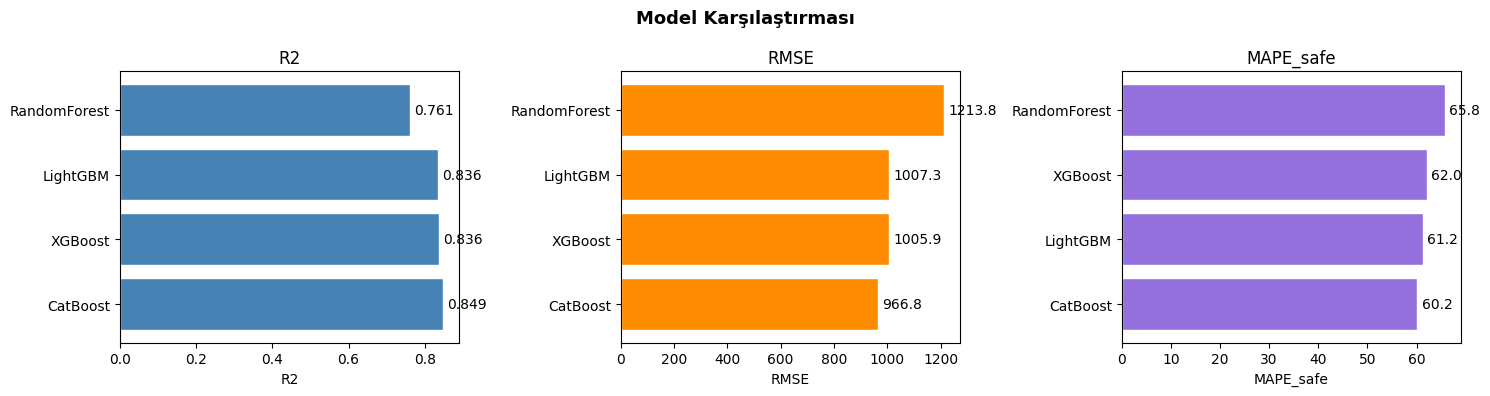

In [20]:
# Leaderboard görsel
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [('R2', True, 'steelblue'), ('RMSE', False, 'darkorange'), ('MAPE_safe', False, 'mediumpurple')]

for ax, (metric, higher_better, color) in zip(axes, metrics):
    data = leaderboard.sort_values(metric, ascending=not higher_better)
    bars = ax.barh(data['Model'], data[metric], color=color, edgecolor='white')
    ax.bar_label(bars, fmt='%.3f' if metric == 'R2' else '%.1f', padding=3)
    ax.set_title(metric)
    ax.set_xlabel(metric)

plt.suptitle('Model Karşılaştırması', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Tahmin Karşılaştırması (Scatter)

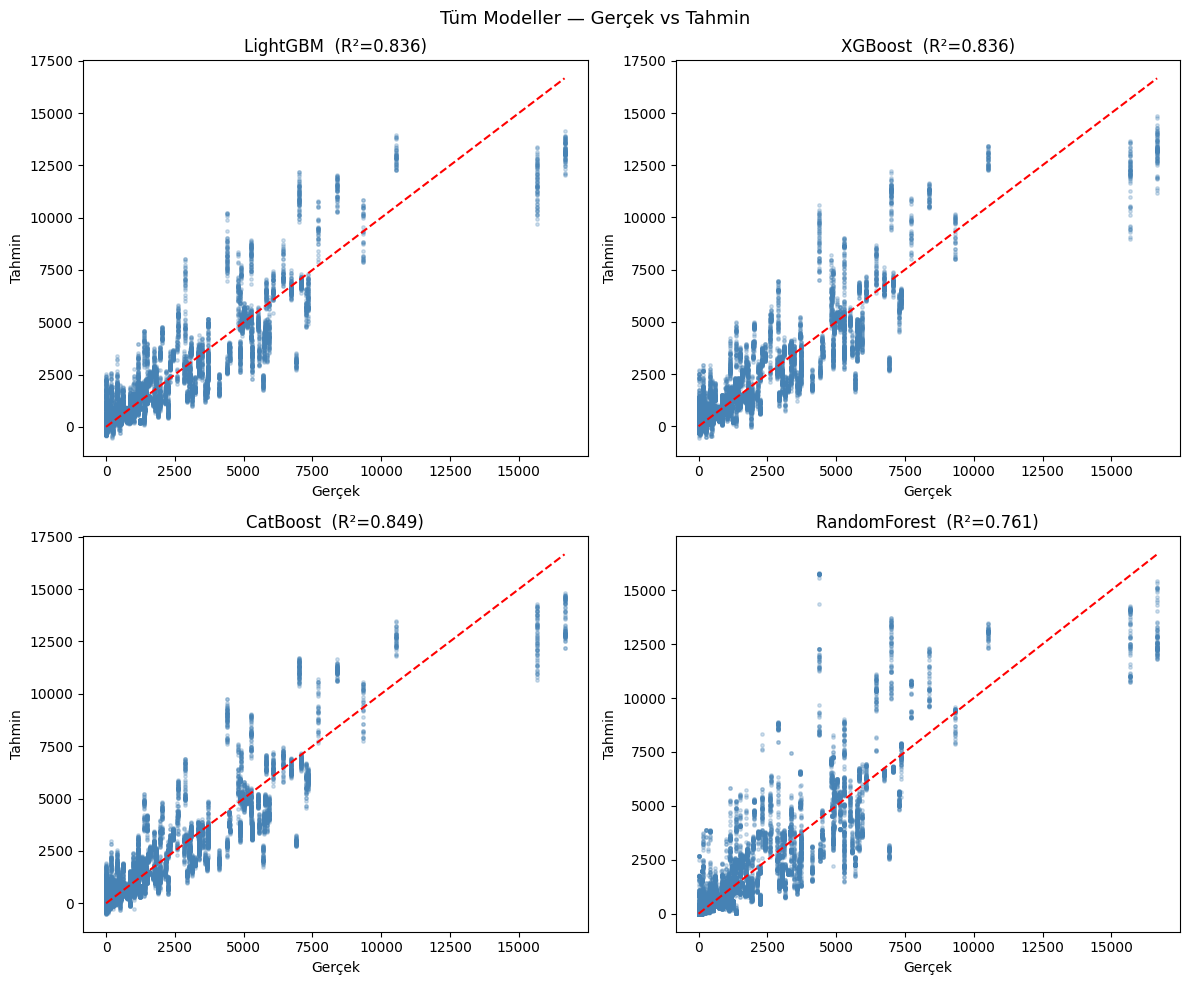

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, preds) in zip(axes.flat, all_preds.items()):
    r2c = r2_score(y_test, preds)
    ax.scatter(y_test, preds, alpha=0.25, s=6, color='steelblue')
    lims = [y_test.min(), y_test.max()]
    ax.plot(lims, lims, 'r--', lw=1.5)
    ax.set_title(f'{name}  (R²={r2c:.3f})')
    ax.set_xlabel('Gerçek')
    ax.set_ylabel('Tahmin')

plt.suptitle('Tüm Modeller — Gerçek vs Tahmin', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Kazanan Modeli Kaydet

In [22]:
winner_model = MODELS[WINNER]
winner_path  = MODEL_DIR / 'best_model.pkl'
joblib.dump(winner_model, winner_path)

leaderboard_out = leaderboard.reset_index().rename(columns={'index': 'Rank'})
leaderboard_out = leaderboard_out[['Rank', 'Model', 'RMSE', 'MAE', 'R2', 'MAPE_safe', 'CV_RMSE_mean', 'CV_RMSE_std', 'Train_sec']]
leaderboard_out.to_csv(MODEL_DIR / 'leaderboard.csv', index=False)

print(f'Kazanan model kaydedildi : {winner_path}')
print(f'Leaderboard kaydedildi   : {MODEL_DIR}/leaderboard.csv')
print(f'\nSonraki adım: 04_inference_pipeline.py')

Kazanan model kaydedildi : /Users/sanlilarburak/Documents/Projects/pcse-ml/models/best_model.pkl
Leaderboard kaydedildi   : /Users/sanlilarburak/Documents/Projects/pcse-ml/models/leaderboard.csv

Sonraki adım: 04_inference_pipeline.py
